### **Authors:**

Juan Navarro - s1097545  
Lola Miranda López - s1198696

*Add your names + s number when possible*


## Part 1: Loading the data

**Load the train, dev and test sets into pandas DataFrames.**

**What we do:**
1. Read the three CSV files (train, dev and test).
2. Check the shape and columns of each set (snippet ID, 'text', 'author').
3. Fix the text: contractions appear with a double quote instead of an apostrophe (e.g. wasn"t), so we restore the apostrophe (wasn't).
4. Check the number of snippets per author.

**Output:** three cleaned DataFrames: 'train', 'dev' and 'test'.

In [1]:
%pip install pandas numpy spacy scikit-learn
!python -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 2.8 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/16.4 MB 3.0 MB/s eta 0:00:05
   --- ------------------------------------ 1.6/16.4 MB 2.7 MB/s eta 0:00:06
   ----- ---------------------------------- 2.1/16.4 MB 2.6 MB/s eta 0:00:06
   ------ --------------------------------- 2.6/16.4 MB 2.6 MB/s eta 0:00:06
   ------- -------------------------------- 3.1/16.4 MB 2.6 MB/s eta 0:00:06
   --------- ------------------------------ 3.9/16.4 MB 2.6 MB/s eta 0:00:05
   ---------- ----------------------------- 4.2/16.4 MB 2.5 MB/s eta 0:00:05
   ----------- ---------------------------- 4.7/16.4 MB 2.5 MB/s eta 0:00:05
   ------------ --------------------------- 5.2/16.4 MB 2.4 MB/s eta 0:00:05
   -------------- ------------------------- 5.8/16.4 MB 2.5 MB/s eta 0:00:05
   --------------- ------------------------ 6.3/16.4 MB 2.4 MB/s eta 0:00:05
   ---


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.1 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 2.0 MB/s eta 0:00:06
     ---- ----------------------------------- 1.6/12.8 MB 2.0 MB/s eta 0:00:06
     ------ --------------------------------- 2.1/12.8 MB 2.0 MB/s eta 0:00:06
     -------- ------------------------------- 2.6/12.8 MB 2.0 MB/s eta 0:00:05
     --------- ------------------------------ 2.9/12.8 MB 2.1 MB/s eta 0:00:05
     ---------- ----------------------------- 3.4/12.8 MB 2.1 MB/s eta 0:00:05
     ------------ --------------------------- 3.9/12.8 MB 2.1 MB/s eta 0:00:05
     ------------- -------------------------- 4.5/12.8 MB 2.1 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.2 MB/s eta 0:00:04
     ---------------- ----------------------- 5.2/12.8 MB 2.2 MB/s


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import re
import pandas as pd
import numpy as np
import spacy
from collections import Counter
from sklearn.preprocessing import StandardScaler



In [3]:
#1 Import the csv files as pandas dataframes
train = pd.read_csv('data/pan2627_train_data.csv', index_col=0).rename_axis('id')
dev   = pd.read_csv('data/pan2627_dev_data.csv',   index_col=0).rename_axis('id')
test  = pd.read_csv('data/pan2627_test_data.csv',  index_col=0).rename_axis('id')

#2 Check shapes, columns and author counts
for name, df in [('train', train), ('dev', dev), ('test', test)]:
    print(f'{name}: {df.shape[0]} snippets, columns: {list(df.columns)}')

counts = train['author'].value_counts().sort_index()
print()
print('Number of different authors in train:', train['author'].nunique())
print(f'Fewest snippets for one author: {counts.min()}, most: {counts.max()}')
print()
print('Snippets per author (train):')
print(counts.to_frame('snippets'))

train: 2138 snippets, columns: ['text', 'author']
dev: 268 snippets, columns: ['text', 'author']
test: 267 snippets, columns: ['text', 'author']

Number of different authors in train: 20
Fewest snippets for one author: 51, most: 150

Snippets per author (train):
         snippets
author           
29783          91
240213         98
512464        112
560480        150
583064        130
583994         83
748687        120
806976        130
870118        141
910821         92
967934         99
1112924        93
1220273       100
1276465       121
1497577       109
2750536       132
2855986       117
2943978        51
3439302        98
6234395        71


In [4]:
#3 Fix the text (i.e. the contractions)
for df in (train, dev, test):
    df['text'] = df['text'].str.replace(r'(?<=[A-Za-z])"(?=[a-z])', "'", regex=True)

# Check that it worked
print(train['text'].iloc[0][:300])

My legs were a bit shaky, so he wrapped an arm around my waist to steady me, "Come on." There was no arguing with the Englishman, and he led me from the room as Italy tended to Germany. The hallways were filled with recovering soldiers, but for the most part the base was quiet. I wasn't used to it, 


## Part 2: Feature extraction

**Goal:** To turn each snippet into numbers that the classifier can use. At least 50 features, both lexical and syntactic organised into groups.

**What we do:**
1. Define the feature groups: lexical, character-level, function words, syntactic (POS tags) and fanfiction-specific.

    - Lexical: average word length, spread of word length, average sentence length, spread of sentence length...
    - Character-level: frequency of ecah punctuation mark, share of uppercase letters, share of digits...
    - Function words: relative frequency of common words (the, of, but...)
    - syntactic (POS tags): relative frequency of each POS tag (noun, verb, adjectiv, adverb...)

2. Write one function per group that takes the snippets and returns a table with one column per feature.
3. Apply the functions to train, dev and test so all three sets have exactly the same columns.
4. Combine the groups into one feature table per set.
5. Check the total number of features (at least 50) and the number of features per group.

**Output:** one feature table for each of 'train', 'dev' and 'test' and a list that shows which features belong to which group.

In [5]:
# 1. Define feature groups
feature_groups = {
    'lexical':        'lex_',
    'character':      'char_',
    'function_words': 'func_',
    'pos':            'pos_',
    'fanfic':         'fan_',
}

# Split snippets into words
def get_words(text):
    text = text.lower()
    tokens = text.split()
    words = []
    for token in tokens:
        word = token.strip('.,!?;:"\'()*-')
        if word:
            words.append(word)
    return words

# Split snippet into sentences
def get_sentences(text):
    parts = re.split(r'(?<=[.!?])\s+|(?<=[.!?]")\s+', text)
    sentences = []
    for part in parts:
        if part.strip():
            sentences.append(part)
    return sentences


In [6]:
# 2. Functions per group

# Lexical group
def lexical_features(texts):
    rows = []

    for text in texts:
        words = get_words(text)
        sentences = get_sentences(text)

        # Length of each word 
        word_lengths = []
        for word in words:
            word_lengths.append(len(word))
        word_lengths = np.array(word_lengths)

        # Length of each sentence
        sentence_lengths = []
        for sentence in sentences:
            sentence_lengths.append(len(get_words(sentence)))
        sentence_lengths = np.array(sentence_lengths)

        # How often each word occurs
        word_counts = Counter(words)

        # Number of words that occur once
        once_only = 0
        for count in word_counts.values():
            if count == 1:
                once_only += 1

        rows.append({
            'lex_avg_word_len': word_lengths.mean(),
            'lex_std_word_len': word_lengths.std(),
            'lex_avg_sent_len': sentence_lengths.mean(),
            'lex_std_sent_len': sentence_lengths.std(),
            'lex_ttr': len(word_counts) / len(words),
            'lex_hapax_ratio': once_only / len(words),
            'lex_long_word_share': (word_lengths >= 7).mean(),
            'lex_short_word_share': (word_lengths <= 3).mean(),
        })

    return pd.DataFrame(rows, index=texts.index)

In [7]:
# Character-level group
punct = {
    ',': 'comma',
    '.': 'period',
    ';': 'semicolon',
    ':': 'colon',
    '!': 'exclamation',
    '?': 'question',
    '-': 'hyphen',
    '(': 'parenthesis',
    '"': 'quote',
    "'": 'apostrophe',
    '*': 'asterisk',
}

def character_features(texts):
    rows = []

    for text in texts:
        n_chars = len(text)
        row = {}

        # How many times each happen
        for mark, name in punct.items():
            row['char_' + name] = text.count(mark) / n_chars

        # How many times '...' happens
        row['char_ellipsis'] = text.count('...') / n_chars

        # Uppercase letters
        n_upper = 0
        for char in text:
            if char.isupper():
                n_upper += 1
        row['char_upper_share'] = n_upper / n_chars

        # Digits
        n_digits = 0
        for char in text:
            if char.isdigit():
                n_digits += 1
        row['char_digit_share'] = n_digits / n_chars

        rows.append(row)

    return pd.DataFrame(rows, index=texts.index)

In [8]:
# Fucntion words
function_words = [
    'the', 'a', 'an', 'and', 'but', 'or', 'nor', 'so', 'yet', 'for', 'of', 'in', 'on', 'at',
    'to', 'from', 'by', 'with', 'about', 'against', 'between', 'into', 'through', 'during',
    'before', 'after', 'above', 'below', 'up', 'down', 'out', 'off', 'over', 'under', 'again',
    'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both',
    'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'not', 'only', 'own', 'same',
    'than', 'too', 'very', 'can', 'will', 'just', 'should', 'now', 'i', 'me', 'my', 'mine',
    'myself', 'we', 'us', 'our', 'you', 'your', 'he', 'him', 'his', 'she', 'her', 'hers', 'it',
    'its', 'they', 'them', 'their', 'this', 'that', 'these', 'those', 'who', 'whom', 'which',
    'what', 'whose', 'is', 'am', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has',
    'had', 'do', 'does', 'did', 'would', 'could', 'might', 'must', 'shall', 'may', 'if',
    'because', 'while', 'as', 'until', 'though', 'although', 'however', 'also', 'even',
    'still', 'almost', 'perhaps', 'maybe', 'often', 'always', 'never',
]

def function_word_features(texts):
    rows = [] 

    for text in texts:
        words = get_words(text)
        n_words = len(words)
        word_counts = Counter(words) # how many of each word
        row = {}

        # how many of each function word
        for word in function_words:
            row['func_' + word] = word_counts[word] / n_words

        rows.append(row)

    return pd.DataFrame(rows, index=texts.index)

In [9]:
# POS tagging
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'lemmatizer']) # a tagger

pos_tags = ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ'
            , 'SYM', 'VERB', 'X']

pos_bigrams = [('DET', 'NOUN'), ('ADJ', 'NOUN'), ('PRON', 'VERB'), ('NOUN', 'VERB'), ('VERB', 'ADP'), ('ADP', 'DET'), 
                ('VERB', 'ADV'), ('ADV', 'VERB'), ('PUNCT', 'PRON'), ('AUX', 'VERB')]


def pos_features(texts):
    rows = []

    for doc in nlp.pipe(texts, batch_size=50):

        # All POS tags
        tags = []
        for token in doc:
            if token.pos_ != 'SPACE':
                tags.append(token.pos_)

        n_tags = len(tags)
        tag_counts = Counter(tags)                  # how often each tag occurs
        pair_counts = Counter(zip(tags, tags[1:]))  # how often each pair of tags occurs
        row = {}

        # Individual POS tag
        for tag in pos_tags:
            row['pos_' + tag] = tag_counts[tag] / n_tags

        # Pairwise POS tag
        for first, second in pos_bigrams:
            row['pos_' + first + '_' + second] = pair_counts[(first, second)] / n_tags

        rows.append(row)

    return pd.DataFrame(rows, index=texts.index)

In [10]:
# 3. Apply functions to all data, to have the same columns
feature_tables = {}

for name, df in [('train', train), ('dev', dev), ('test', test)]:
    feature_tables[name] = {
        'lexical':        lexical_features(df['text']),
        'character':      character_features(df['text']),
        'function_words': function_word_features(df['text']),
        'pos':            pos_features(df['text']),
    }
    print(name, 'done')


for name in feature_tables:
    for group, table in feature_tables[name].items():
        print(f'{name:5} {group:15} {table.shape}')

train done
dev done
test done
train lexical         (2138, 8)
train character       (2138, 14)
train function_words  (2138, 133)
train pos             (2138, 27)
dev   lexical         (268, 8)
dev   character       (268, 14)
dev   function_words  (268, 133)
dev   pos             (268, 27)
test  lexical         (267, 8)
test  character       (267, 14)
test  function_words  (267, 133)
test  pos             (267, 27)


In [11]:
# 4. COmbine into one feature table

X_train = pd.concat(feature_tables['train'].values(), axis=1)
X_dev   = pd.concat(feature_tables['dev'].values(),   axis=1)
X_test  = pd.concat(feature_tables['test'].values(),  axis=1)

# The labels: the author of each snippet
y_train = train['author']
y_dev   = dev['author']
y_test  = test['author']

# Check: shapes, same columns in all three sets, and no missing values
print('Shapes:', X_train.shape, X_dev.shape, X_test.shape)
print('Same columns in all sets:', list(X_train.columns) == list(X_dev.columns) == list(X_test.columns))
print('Missing values in train:', X_train.isna().sum().sum())

Shapes: (2138, 182) (268, 182) (267, 182)
Same columns in all sets: True
Missing values in train: 0


In [12]:
# 5. Chek number of features and number of feature per group
print('Total number of features:', X_train.shape[1])
print()
for group, prefix in feature_groups.items():
    n_features = X_train.columns.str.startswith(prefix).sum()
    print(f'{group:15} {n_features} features')

Total number of features: 182

lexical         8 features
character       14 features
function_words  133 features
pos             27 features
fanfic          0 features


## Part 3: Classifier and tuning

**Goal:** To build a classifier that predicts the author of a snippet from its features, and tune it using the training and development sets.

**What we do:**
1. Scale the features so they are on a simialr range. The scaler is fitted on train only and then applied to dev and test.
2. Train a few candidate classifiers on the train set:

    - Logistic Regression
    - Linear SVM
    - Random Forest

3. Compare the candidates on the dev set using macro F1.
4. Tune the setings of the best classifiers on the dev set.
5. Keep the best classifier with its settings.

**Output:** the final classifier with its tuned settings and a table with the dev macro F1 of each candidate.

In [13]:
# 1. Scale feature, fit on train and appleid to dev and test
scaler = StandardScaler()
scaler.fit(X_train)

# apply the same scaling to train, dev and test 
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_dev_scaled   = pd.DataFrame(scaler.transform(X_dev),   columns=X_dev.columns,   index=X_dev.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

print('Train: average of column means =', X_train_scaled.mean().mean().round(3))
print('Train: average of column std   =', X_train_scaled.std(ddof=0).mean().round(3))
print('Dev:   average of column means =', X_dev_scaled.mean().mean().round(3))
print('Dev:   average of column std   =', X_dev_scaled.std(ddof=0).mean().round(3))

Train: average of column means = -0.0
Train: average of column std   = 1.0
Dev:   average of column means = -0.006
Dev:   average of column std   = 0.985


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

# Define candidate classifiers
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        max_iter=10000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

# Train and evaluate each model
results = []

for name, model in models.items():

    # Train on the training set
    model.fit(X_train_scaled, y_train)

    # Predict authors in the development set
    y_pred = model.predict(X_dev_scaled)

    # Evaluate predictions
    macro_f1 = f1_score(y_dev, y_pred, average="macro")
    accuracy = accuracy_score(y_dev, y_pred)

    results.append({
        "Model": name,
        "Macro F1": macro_f1,
        "Accuracy": accuracy
    })

# Compare results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
)

print(results_df.to_string(index=False))

              Model  Macro F1  Accuracy
Logistic Regression  0.859851  0.884328
      Random Forest  0.826678  0.869403
         Linear SVM  0.812492  0.843284


In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline

# Define cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define a pipeline
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)

# Hyperparameters to test
param_grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100]
}

# Search for the best hyperparameter
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Fit using only training data
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV Macro F1:", grid.best_score_)

# Evaluate on development set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_dev)

print("Dev Macro F1:", f1_score(y_dev, y_pred, average="macro"))
print("Dev Accuracy:", accuracy_score(y_dev, y_pred))

Best C: {'logisticregression__C': 0.1}
Best CV Macro F1: 0.9118790638705357
Dev Macro F1: 0.8654182285517708
Dev Accuracy: 0.8880597014925373


## Part 4: Evaluation

**Goal:** measure how well the final classifier performs on the development set, and to check whether feature selection helps. The target is at least 0.7

**What we do:**
1. Preditc the authors of the dev snippets with the final classifier from Part 3.
2. Calculate the scores:

    - Macro F1 (the main score, because the classes are imbalanced)
    - Accuracy
    - Precision, recall and F1 for each author

3. Plot a confusion matrix to see which authors get mixed up. We need this for the failure analysis in the report.
4. Test feature selection (e.g. keeping only the k best features) and compare the dev macro F1 with and without it.
5. Decide whether feature selection is useful in our case.

**Output:** the dev scores (overall and per author), the confusion matrix and a comparison of the results with and without feature selection.

              precision    recall  f1-score   support

       29783       1.00      1.00      1.00        11
      240213       1.00      0.83      0.91         6
      512464       0.90      1.00      0.95        18
      560480       0.95      0.90      0.93        21
      583064       0.88      1.00      0.93        14
      583994       0.89      0.80      0.84        10
      748687       0.93      1.00      0.96        13
      806976       1.00      1.00      1.00        21
      870118       0.58      0.73      0.65        15
      910821       1.00      1.00      1.00        14
      967934       0.89      0.73      0.80        11
     1112924       0.90      1.00      0.95        19
     1220273       0.71      0.91      0.80        11
     1276465       0.86      0.86      0.86         7
     1497577       0.80      0.67      0.73        18
     2750536       0.95      1.00      0.97        18
     2855986       0.92      0.80      0.86        15
     2943978       0.75    

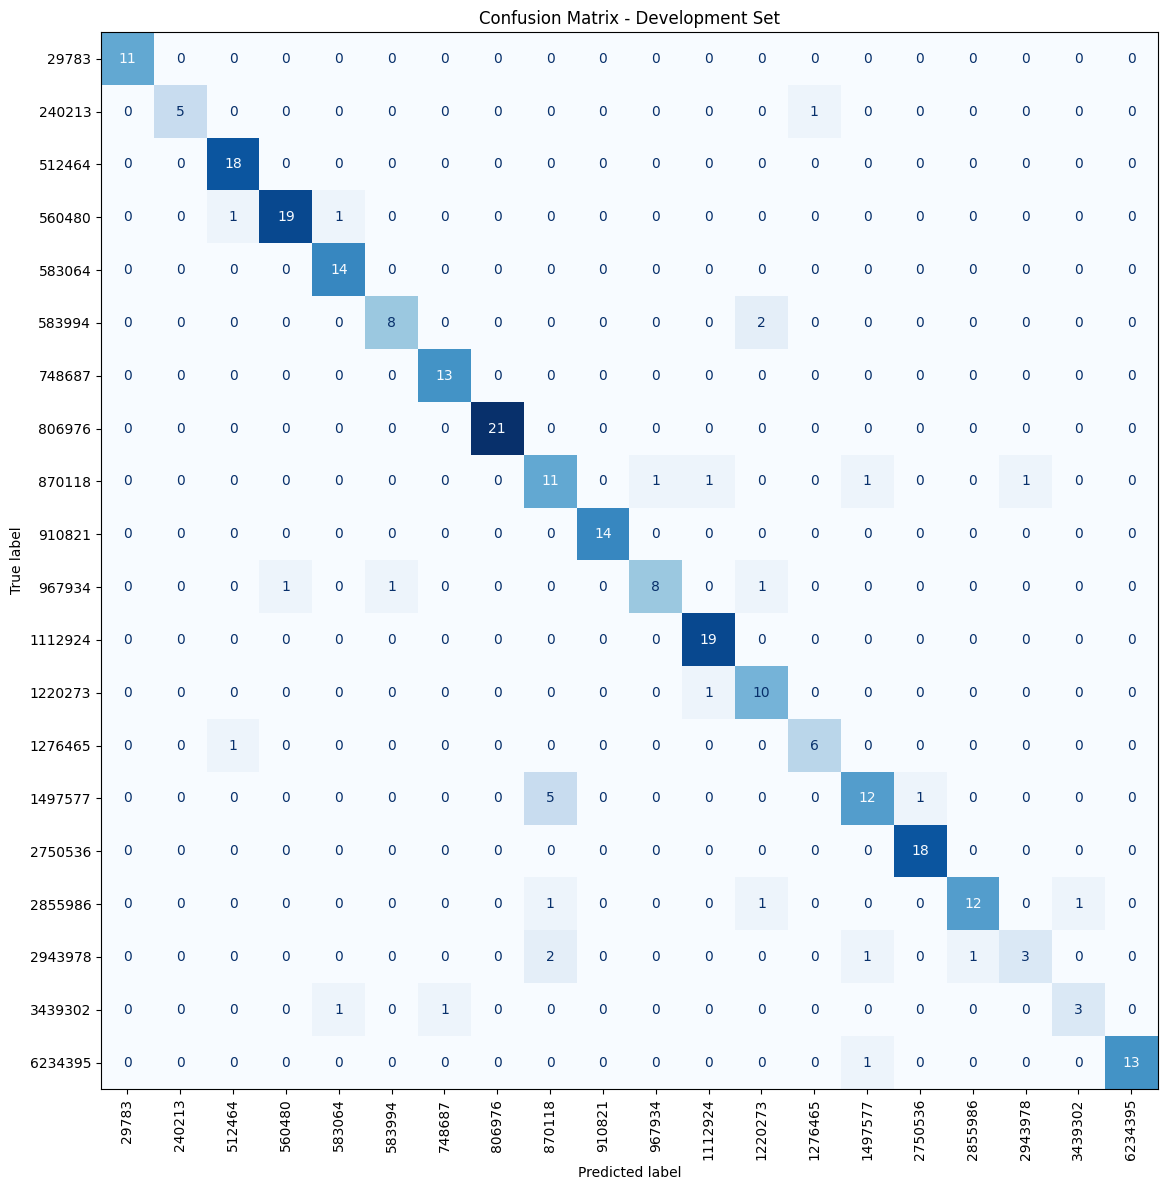

In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict using the tuned classifier
y_pred = best_model.predict(X_dev)

# Classification report
print(classification_report(
    y_dev,
    y_pred,
    zero_division=0
))

# Confusion matrix
labels = best_model.classes_

cm = confusion_matrix(
    y_dev,
    y_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix - Development Set")
plt.tight_layout()
plt.show()

In [17]:
# Find the most common classification mistakes

import numpy as np

errors = []

for i, true_author in enumerate(labels):
    for j, predicted_author in enumerate(labels):

        if i != j and cm[i, j] > 0:
            errors.append({
                "True author": true_author,
                "Predicted author": predicted_author,
                "Number of errors": cm[i, j]
            })

errors_df = pd.DataFrame(errors)

errors_df = errors_df.sort_values(
    by="Number of errors",
    ascending=False
)

print(errors_df.head(15).to_string(index=False))

 True author  Predicted author  Number of errors
     1497577            870118                 5
      583994           1220273                 2
     2943978            870118                 2
      240213           1276465                 1
      870118            967934                 1
      870118           1112924                 1
      560480            512464                 1
      560480            583064                 1
      870118           2943978                 1
      870118           1497577                 1
      967934           1220273                 1
      967934            560480                 1
     1220273           1112924                 1
     1276465            512464                 1
     1497577           2750536                 1


In [20]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Number of features to test
k_values = [30, 50, 75, 100, 125, 150, 182]

selection_results = []

for k in k_values:

    # Create pipeline
    model = make_pipeline(
        StandardScaler(),
        SelectKBest(score_func=f_classif, k=k),
        LogisticRegression(
            C=0.1,
            max_iter=5000,
            random_state=42
        )
    )

    # Cross-validation using training data only
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    selection_results.append({
        "Features": k,
        "CV Macro F1": scores.mean()
    })

# Display results
selection_df = pd.DataFrame(selection_results)

print(selection_df.to_string(index=False))

 Features  CV Macro F1
       30     0.759453
       50     0.823183
       75     0.862850
      100     0.879035
      125     0.902164
      150     0.909030
      182     0.911879


## Part 5: Ablation analysis

**Goal:** find out which feature group is the most informative for the classifier by removing one group at a time and checking how the performance changes.

**What we do:**
1. Train the final classifier with all feature groups and record the dev macro F1. This is the baseline (no groups removed).
2. For each feature group:

    - Remove all features of that group
    - Retrain the classifier with the same settings
    - Record the dev macro F1

3. Plot the results as a bar chart in the style of Figure 1 of the assignment: one bar for the baseline and one bar for each removed group.
4. Compare the bars: the group dropping the most in F1 score is the most informative.

**Output:** a bar chart saved in the results folder and a table with the dev macro F1 for each removed group.

In [18]:
from sklearn.base import clone
from sklearn.metrics import f1_score
import pandas as pd

# Baseline: all 182 features
baseline_pred = best_model.predict(X_dev)
baseline_f1 = f1_score(y_dev, baseline_pred, average="macro")

ablation_results = [{
    "Removed group": "None (all features)",
    "Number of features": X_train.shape[1],
    "Macro F1": baseline_f1
}]

# Remove one feature group at a time
for group, prefix in feature_groups.items():

    # Find features belonging to this group
    group_cols = [
        col for col in X_train.columns
        if col.startswith(prefix)
    ]

    # Skip empty groups (e.g. fanfic)
    if not group_cols:
        continue

    # Remove the group's features
    remaining_cols = X_train.columns.difference(
        group_cols, sort=False
    )

    # Create a fresh copy of the tuned classifier
    model = clone(best_model)

    # Train without the removed features
    model.fit(X_train[remaining_cols], y_train)

    # Predict on development
    predictions = model.predict(X_dev[remaining_cols])

    # Calculate Macro F1
    score = f1_score(
        y_dev,
        predictions,
        average="macro"
    )

    ablation_results.append({
        "Removed group": group,
        "Number of features": len(remaining_cols),
        "Macro F1": score
    })

# Results table
ablation_df = pd.DataFrame(ablation_results)

ablation_df["F1 drop"] = (
    baseline_f1 - ablation_df["Macro F1"]
)

print(ablation_df.to_string(index=False))

      Removed group  Number of features  Macro F1  F1 drop
None (all features)                 182  0.865418 0.000000
            lexical                 174  0.837906 0.027513
          character                 168  0.837515 0.027903
     function_words                  49  0.801698 0.063720
                pos                 155  0.835560 0.029859


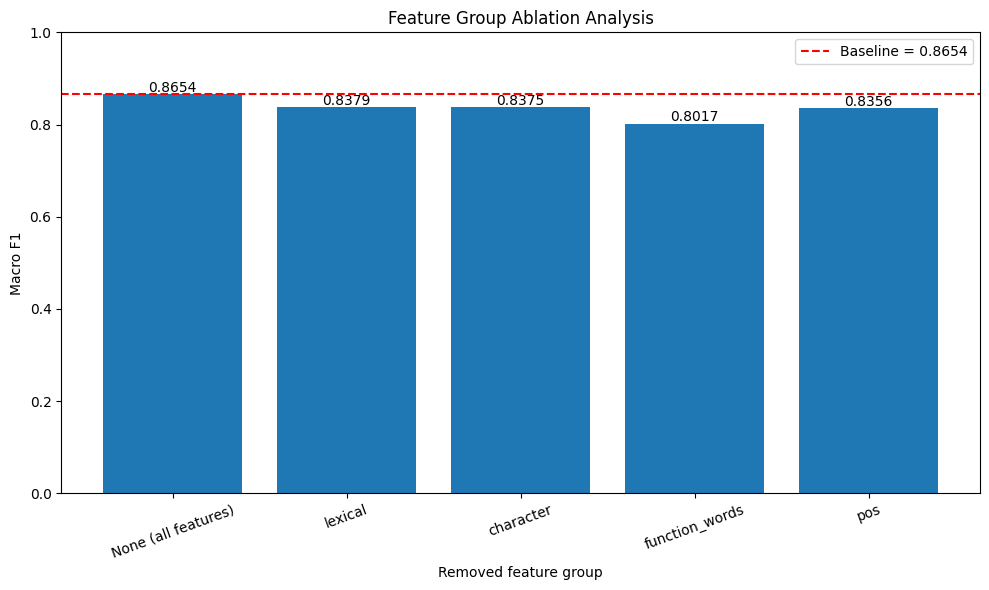

In [19]:
import matplotlib.pyplot as plt

# Prepare data for visualization
labels = ablation_df["Removed group"]
scores = ablation_df["Macro F1"]

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, scores)

# Baseline reference
plt.axhline(
    y=baseline_f1,
    color="red",
    linestyle="--",
    label=f"Baseline = {baseline_f1:.4f}"
)

# Show F1 values above each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center"
    )

plt.xlabel("Removed feature group")
plt.ylabel("Macro F1")
plt.title("Feature Group Ablation Analysis")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.savefig("ablation_analysis.png", dpi=300)
plt.show()

## Part 6: Test set

**Goal:** run the final classifier on the unseen test set and see how well it generalises. The test set is used once and nothing is changed after seeing the result.

**What we do:**
1. Take the final classifier with its settings and the selected features.
2. Predict the authors of the test snippets.
3. Calculate the same scores as for the dev set:

    - Macro F1 and accuracy
    - Precision, recall and F1 for each author

4. Plot the confusion matrix for the test set.
5. Compare the test scores with the dev scores and note any difference.

**Output:** the test scores (overall and per author), the confusion matrix and a comparison of dev and test performance.

In [23]:
# Final evaluation on the unseen test set

y_test_pred = best_model.predict(X_test)

test_f1 = f1_score(y_test, y_test_pred, average="macro")
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Development Macro F1:", baseline_f1)
print("Test Macro F1:", test_f1)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

Development Macro F1: 0.8654182285517708
Test Macro F1: 0.9066105168210126
Test Accuracy: 0.9176029962546817

Classification Report:
              precision    recall  f1-score   support

       29783       0.94      1.00      0.97        16
      240213       1.00      0.87      0.93        15
      512464       0.75      0.92      0.83        13
      560480       0.94      0.94      0.94        17
      583064       0.93      1.00      0.96        13
      583994       1.00      0.91      0.95        11
      748687       0.95      1.00      0.98        20
      806976       1.00      0.80      0.89        15
      870118       0.92      1.00      0.96        12
      910821       1.00      1.00      1.00        20
      967934       0.94      0.89      0.91        18
     1112924       0.91      1.00      0.95        10
     1220273       0.77      0.83      0.80        12
     1276465       0.93      1.00      0.96        13
     1497577       0.93      0.78      0.85        18
  

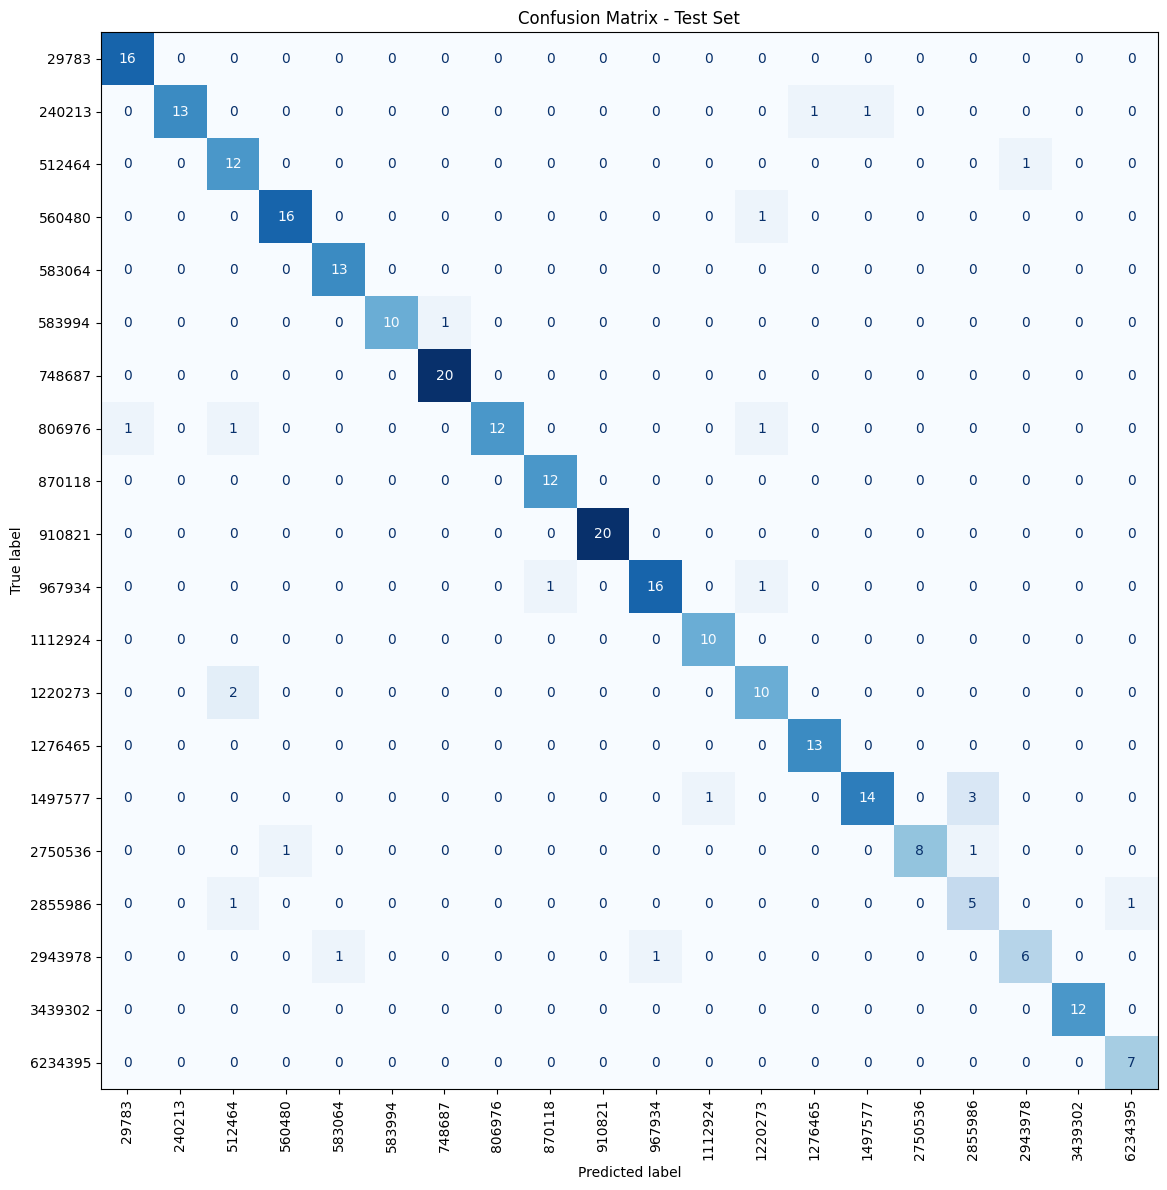

In [24]:
# Confusion Matrix - Test Set

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get author labels
test_labels = best_model.classes_

# Calculate confusion matrix
cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=test_labels
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=test_labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix - Test Set")
plt.tight_layout()

# Save figure for the report
plt.savefig("test_confusion_matrix.png", dpi=300)

plt.show()

In [25]:
# Confusion matrix with totals

cm_df = pd.DataFrame(
    cm_test,
    index=test_labels,
    columns=test_labels
)

# Total real snippets per author
cm_df["Total"] = cm_df.sum(axis=1)

# Total predictions per author
cm_df.loc["Total"] = cm_df.sum(axis=0)

display(cm_df)

,29783,240213,512464,560480,583064,583994,748687,806976,870118,910821,...,1112924,1220273,1276465,1497577,2750536,2855986,2943978,3439302,6234395,Total
29783,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,16
240213,0,13,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,15
512464,0,0,12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,13
560480,0,0,0,16,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,17
583064,0,0,0,0,13,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,13
583994,0,0,0,0,0,10,1,0,0,0,...,0,0,0,0,0,0,0,0,0,11
748687,0,0,0,0,0,0,20,0,0,0,...,0,0,0,0,0,0,0,0,0,20
806976,1,0,1,0,0,0,0,12,0,0,...,0,1,0,0,0,0,0,0,0,15
870118,0,0,0,0,0,0,0,0,12,0,...,0,0,0,0,0,0,0,0,0,12
910821,0,0,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,20


In [26]:
author_summary = pd.DataFrame({
    "Author": test_labels,
    "Total": cm_test.sum(axis=1),
    "Correct": cm_test.diagonal(),
    "Errors": cm_test.sum(axis=1) - cm_test.diagonal()
})

display(author_summary)

,Author,Total,Correct,Errors
0,29783,16,16,0
1,240213,15,13,2
2,512464,13,12,1
3,560480,17,16,1
4,583064,13,13,0
5,583994,11,10,1
6,748687,20,20,0
7,806976,15,12,3
8,870118,12,12,0
9,910821,20,20,0


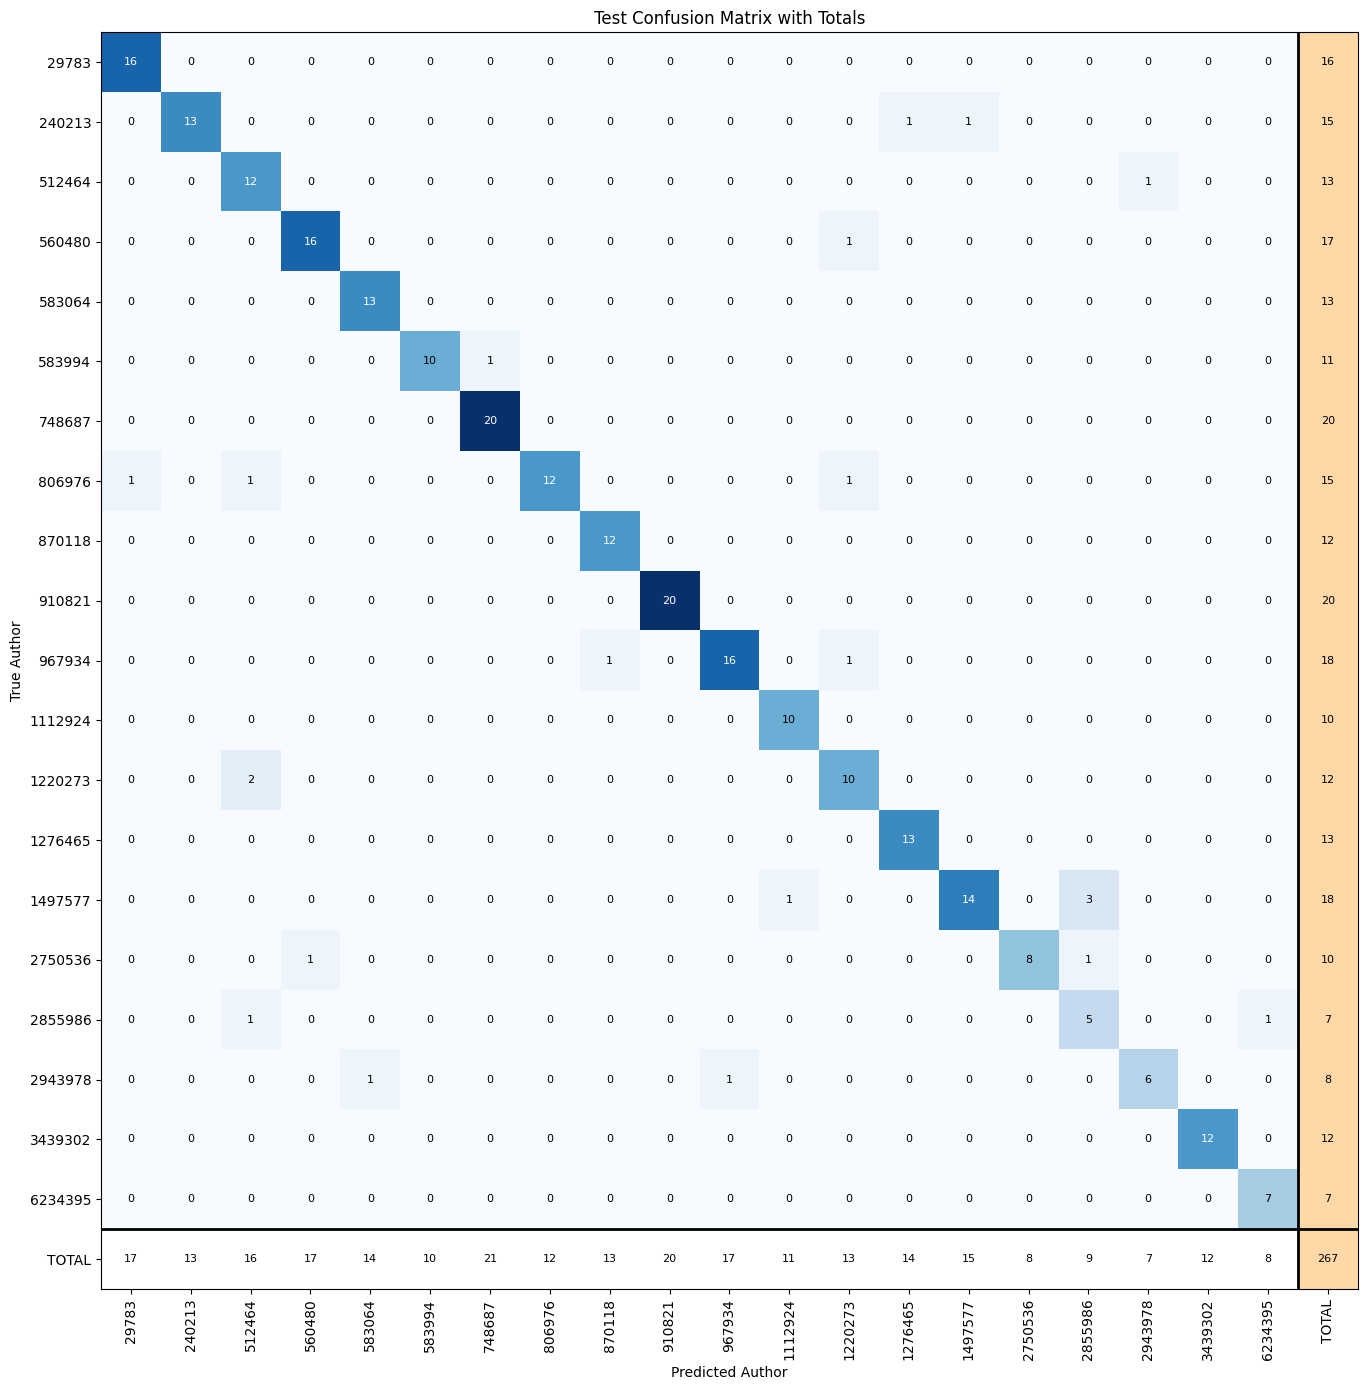

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
test_labels = best_model.classes_

cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=test_labels
)

n = len(test_labels)

# Add an extra row and column for totals
cm_total = np.zeros((n + 1, n + 1), dtype=int)

cm_total[:n, :n] = cm_test

# Last column: total real texts per author
cm_total[:n, n] = cm_test.sum(axis=1)

# Last row: total predictions per author
cm_total[n, :n] = cm_test.sum(axis=0)

# Bottom-right corner: total test texts
cm_total[n, n] = cm_test.sum()

# Keep totals white instead of colouring them
mask = np.zeros_like(cm_total, dtype=bool)
mask[n, :] = True
mask[:, n] = True

display_matrix = np.ma.masked_array(
    cm_total,
    mask=mask
)

fig, ax = plt.subplots(figsize=(16, 14))

ax.imshow(display_matrix, cmap="Blues")
# Highlight the TOTAL column in orange
ax.axvspan(
    n - 0.5,
    n + 0.5,
    color="#FFD8A8",
    zorder=1
)

labels_with_total = list(test_labels) + ["TOTAL"]

ax.set_xticks(range(n + 1))
ax.set_yticks(range(n + 1))

ax.set_xticklabels(labels_with_total, rotation=90)
ax.set_yticklabels(labels_with_total)

# Display all numbers
for i in range(n + 1):
    for j in range(n + 1):
        value = cm_total[i, j]

        color = "white" if (
            i < n and j < n
            and value > cm_test.max() / 2
        ) else "black"

        ax.text(
            j, i, str(value),
            ha="center",
            va="center",
            color=color,
            fontsize=8
        )

# Separate totals from the main matrix
ax.axhline(n - 0.5, color="black", linewidth=2)
ax.axvline(n - 0.5, color="black", linewidth=2)

ax.set_xlabel("Predicted Author")
ax.set_ylabel("True Author")
ax.set_title("Test Confusion Matrix with Totals")

plt.tight_layout()
plt.savefig("test_confusion_matrix.png", dpi=300)
plt.show()